# Petrol Consumption and Ethanol Blending - Exploratory Data Analysis

**Objective:** To explore petrol consumption, price, ethanol blending, vehicle registrations, and air-quality data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(
    r"C:\Users\SWAGATIKA\Documents\E20_Petrol_EDA_Dataset_600_Rows.xlsx",
    engine="openpyxl"
)

df.head()

,Date,Year,Month,State,Petrol_Consumption_000MT,Petrol_Price_INR_L,Ethanol_Blend_Percent,Vehicle_Registrations,AQI,PM2_5,PM10,CO,NO2,Crude_Oil_USD_Barrel
0,2020-01-01,2020,Jan,Delhi,447,74.45,8.5,2807113,122,77,75,1.92,79,58.48
1,2020-01-01,2020,Jan,Maharashtra,336,71.27,8.5,1285972,115,79,169,1.62,81,62.95
2,2020-01-01,2020,Jan,Odisha,399,86.78,8.5,4268238,210,91,247,2.21,30,82.93
3,2020-01-01,2020,Jan,Karnataka,294,81.11,8.5,2306182,255,106,66,0.50,22,69.36
4,2020-01-01,2020,Jan,Tamil Nadu,296,94.15,8.5,864488,246,137,177,0.57,58,58.15


step 1 done

In [8]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Dataset shape: (600, 14)

Column names:
['Date', 'Year', 'Month', 'State', 'Petrol_Consumption_000MT', 'Petrol_Price_INR_L', 'Ethanol_Blend_Percent', 'Vehicle_Registrations', 'AQI', 'PM2_5', 'PM10', 'CO', 'NO2', 'Crude_Oil_USD_Barrel']

Data types:
Date                         object
Year                          int64
Month                        object
State                        object
Petrol_Consumption_000MT      int64
Petrol_Price_INR_L          float64
Ethanol_Blend_Percent       float64
Vehicle_Registrations         int64
AQI                           int64
PM2_5                         int64
PM10                          int64
CO                          float64
NO2                           int64
Crude_Oil_USD_Barrel        float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  ----

step 2 done and convert Date to proper date format

In [9]:
# Convert Date to proper date format
df["Date"] = pd.to_datetime(df["Date"])

# Missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Confirm corrected data types
print("\nUpdated data types:")
print(df.dtypes)

Missing values in each column:
Date                        0
Year                        0
Month                       0
State                       0
Petrol_Consumption_000MT    0
Petrol_Price_INR_L          0
Ethanol_Blend_Percent       0
Vehicle_Registrations       0
AQI                         0
PM2_5                       0
PM10                        0
CO                          0
NO2                         0
Crude_Oil_USD_Barrel        0
dtype: int64

Number of duplicate rows:
0

Updated data types:
Date                        datetime64[ns]
Year                                 int64
Month                               object
State                               object
Petrol_Consumption_000MT             int64
Petrol_Price_INR_L                 float64
Ethanol_Blend_Percent              float64
Vehicle_Registrations                int64
AQI                                  int64
PM2_5                                int64
PM10                                 int64
CO           

missing values and duplicate rows show 0 then data is clean for analysis

step 3 done

In [10]:
# Summary statistics for numeric columns
display(df.describe().T)

# Median values for numeric columns
print("Median values:")
print(df.select_dtypes(include="number").median())

# Number of records by state
print("\nRecords by state:")
print(df["State"].value_counts())

# Number of records by month
print("\nRecords by month:")
print(df["Month"].value_counts())

,count,mean,min,25%,50%,75%,max,std
Date,600,2022-06-16 15:12:00,2020-01-01 00:00:00,2021-03-24 06:00:00,2022-06-16 00:00:00,2023-09-08 12:00:00,2024-12-01 00:00:00,NaN
Year,600.0,2022.0,2020.0,2021.0,2022.0,2023.0,2024.0,1.415394
Petrol_Consumption_000MT,600.0,289.793333,120.0,207.0,295.0,371.0,450.0,94.082285
Petrol_Price_INR_L,600.0,89.8447,70.19,79.6175,89.48,100.2625,109.98,11.593992
Ethanol_Blend_Percent,600.0,11.24,8.5,10.1,10.5,12.1,15.0,2.203291
Vehicle_Registrations,600.0,2812917.508333,509655.0,1740143.5,2856739.0,3917312.25,4999257.0,1265517.835687
AQI,600.0,174.713333,60.0,118.75,180.5,229.0,280.0,63.553465
PM2_5,600.0,100.621667,20.0,59.0,103.0,140.0,180.0,45.909563
PM10,600.0,147.021667,40.0,95.75,149.5,202.0,250.0,62.269122
CO,600.0,1.43635,0.3,0.9075,1.45,1.95,2.5,0.62432


Median values:
Year                           2022.000
Petrol_Consumption_000MT        295.000
Petrol_Price_INR_L               89.480
Ethanol_Blend_Percent            10.500
Vehicle_Registrations       2856739.000
AQI                             180.500
PM2_5                           103.000
PM10                            149.500
CO                                1.450
NO2                              49.000
Crude_Oil_USD_Barrel             74.605
dtype: float64

Records by state:
State
Delhi            60
Maharashtra      60
Odisha           60
Karnataka        60
Tamil Nadu       60
Gujarat          60
West Bengal      60
Uttar Pradesh    60
Punjab           60
Rajasthan        60
Name: count, dtype: int64

Records by month:
Month
Jan    50
Feb    50
Mar    50
Apr    50
May    50
Jun    50
Jul    50
Aug    50
Sep    50
Oct    50
Nov    50
Dec    50
Name: count, dtype: int64


step 4 done

In [11]:
# Check for invalid negative values
checks = {
    "Negative petrol consumption": (df["Petrol_Consumption_000MT"] < 0).sum(),
    "Negative petrol price": (df["Petrol_Price_INR_L"] < 0).sum(),
    "Invalid ethanol blend (<0 or >100)": (
        (df["Ethanol_Blend_Percent"] < 0) |
        (df["Ethanol_Blend_Percent"] > 100)
    ).sum(),
    "Negative vehicle registrations": (df["Vehicle_Registrations"] < 0).sum(),
    "Negative AQI": (df["AQI"] < 0).sum(),
    "Negative PM2.5": (df["PM2_5"] < 0).sum(),
    "Negative PM10": (df["PM10"] < 0).sum(),
    "Negative CO": (df["CO"] < 0).sum(),
    "Negative NO2": (df["NO2"] < 0).sum(),
    "Negative crude-oil price": (df["Crude_Oil_USD_Barrel"] < 0).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

Negative petrol consumption: 0
Negative petrol price: 0
Invalid ethanol blend (<0 or >100): 0
Negative vehicle registrations: 0
Negative AQI: 0
Negative PM2.5: 0
Negative PM10: 0
Negative CO: 0
Negative NO2: 0
Negative crude-oil price: 0


every result is 0 , no invalid values were found


step 5 done

In [12]:
# Detect outliers using the IQR method
numeric_cols = df.select_dtypes(include="number").columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    outlier_summary[col] = outlier_count

print("Outlier count in each numeric column:")
print(pd.Series(outlier_summary).sort_values(ascending=False))

Outlier count in each numeric column:
Year                        0
Petrol_Consumption_000MT    0
Petrol_Price_INR_L          0
Ethanol_Blend_Percent       0
Vehicle_Registrations       0
AQI                         0
PM2_5                       0
PM10                        0
CO                          0
NO2                         0
Crude_Oil_USD_Barrel        0
dtype: int64


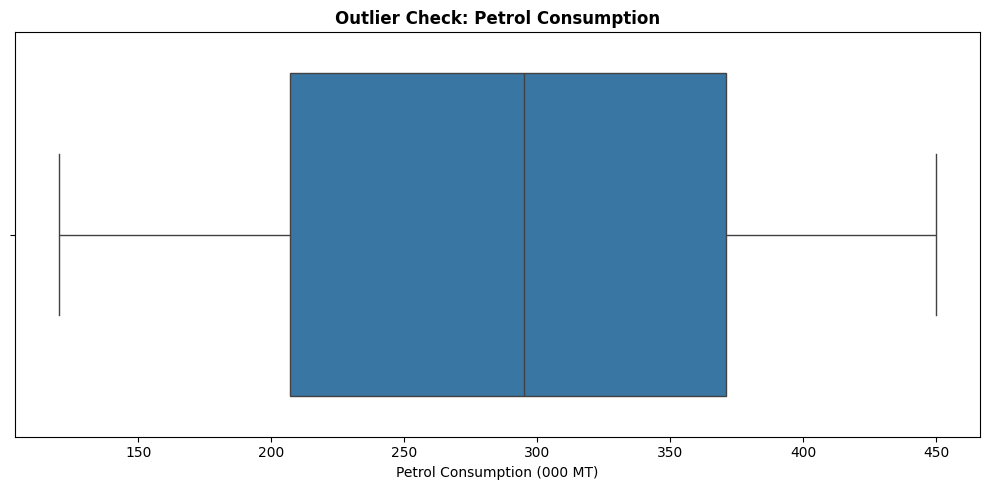

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Petrol_Consumption_000MT",
    color="#2878B5"
)

plt.title("Outlier Check: Petrol Consumption", weight="bold")
plt.xlabel("Petrol Consumption (000 MT)")
plt.tight_layout()
plt.show()

step 6 done

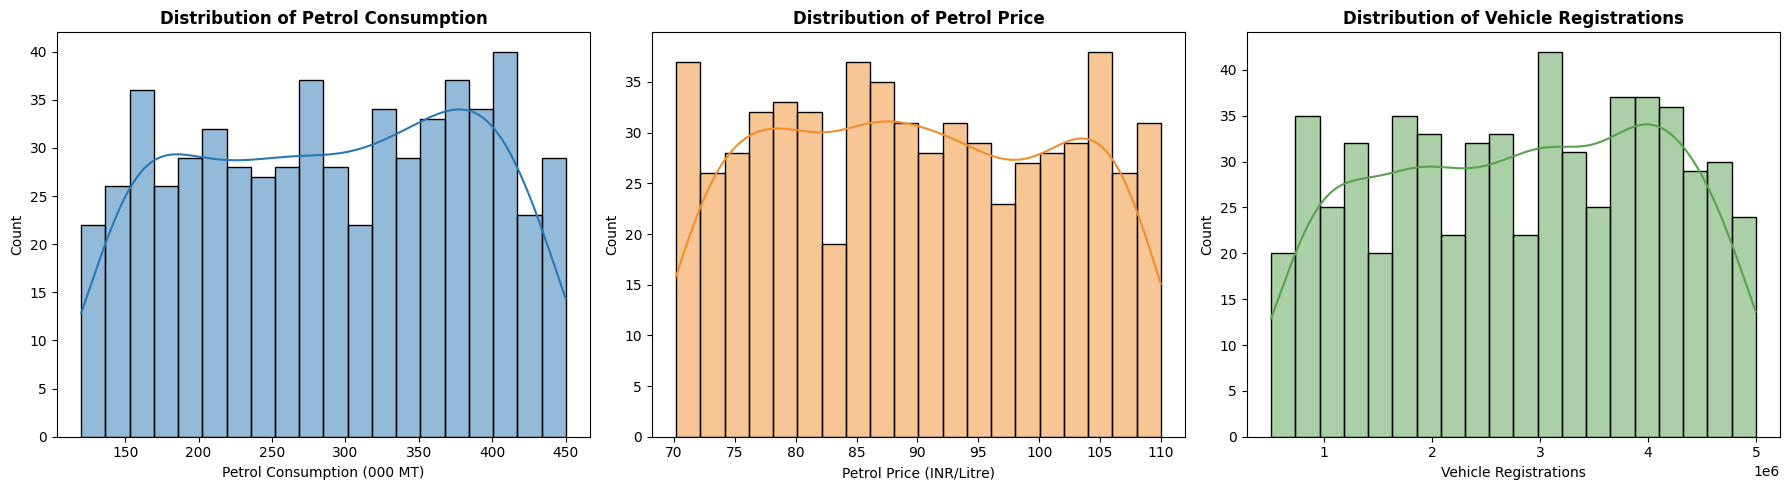

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Petrol consumption distribution
sns.histplot(
    data=df,
    x="Petrol_Consumption_000MT",
    bins=20,
    kde=True,
    color="#2878B5",
    ax=axes[0]
)
axes[0].set_title("Distribution of Petrol Consumption", weight="bold")
axes[0].set_xlabel("Petrol Consumption (000 MT)")

# Petrol price distribution
sns.histplot(
    data=df,
    x="Petrol_Price_INR_L",
    bins=20,
    kde=True,
    color="#F28E2B",
    ax=axes[1]
)
axes[1].set_title("Distribution of Petrol Price", weight="bold")
axes[1].set_xlabel("Petrol Price (INR/Litre)")

# Vehicle registrations distribution
sns.histplot(
    data=df,
    x="Vehicle_Registrations",
    bins=20,
    kde=True,
    color="#59A14F",
    ax=axes[2]
)
axes[2].set_title("Distribution of Vehicle Registrations", weight="bold")
axes[2].set_xlabel("Vehicle Registrations")

plt.tight_layout()
plt.show()

These charts show whether values are evenly spread, concentrated, or skewed.




step 7 done

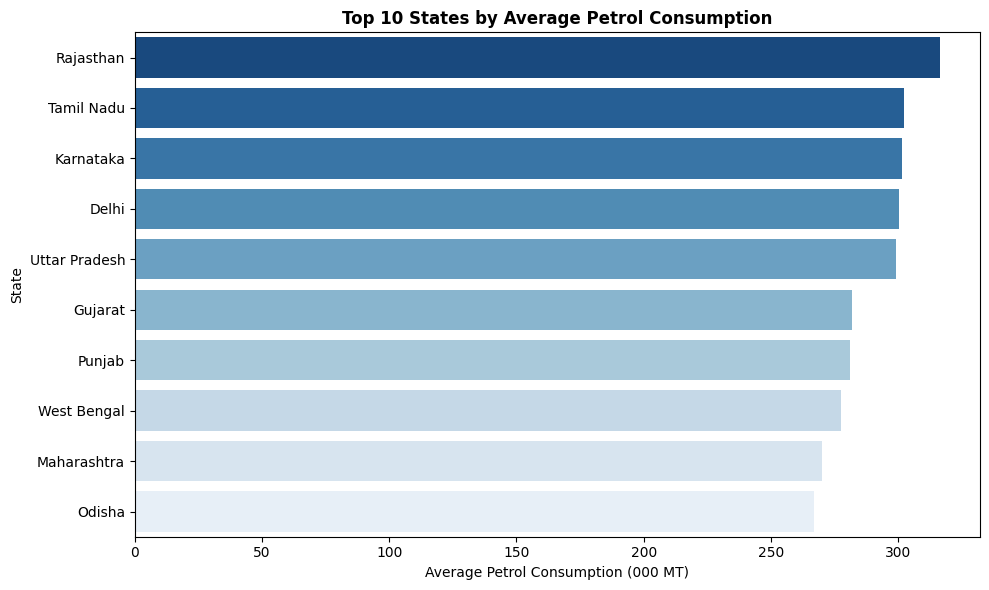

In [15]:
# Top 10 states by average petrol consumption
state_consumption = (
    df.groupby("State")["Petrol_Consumption_000MT"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=state_consumption.values,
    y=state_consumption.index,
    hue=state_consumption.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 States by Average Petrol Consumption", weight="bold")
plt.xlabel("Average Petrol Consumption (000 MT)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

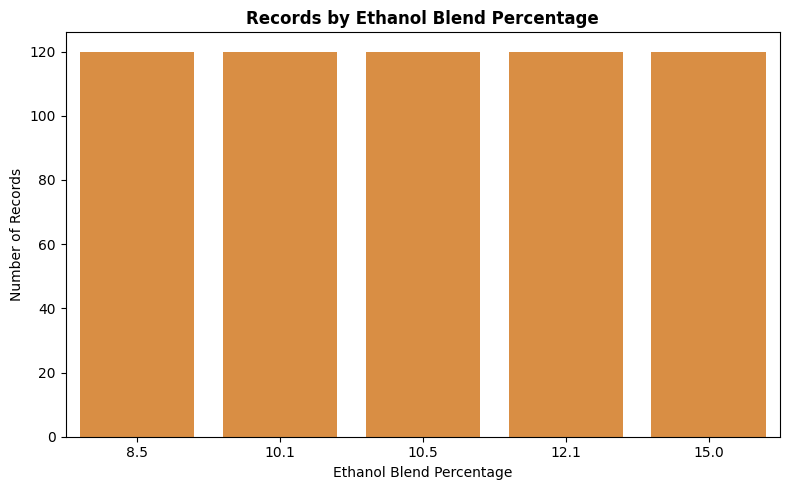

In [16]:
# Count of records for each ethanol-blend percentage
plt.figure(figsize=(8, 5))

order = sorted(df["Ethanol_Blend_Percent"].unique())

sns.countplot(
    data=df,
    x="Ethanol_Blend_Percent",
    order=order,
    color="#F28E2B"
)

plt.title("Records by Ethanol Blend Percentage", weight="bold")
plt.xlabel("Ethanol Blend Percentage")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

step 8 done

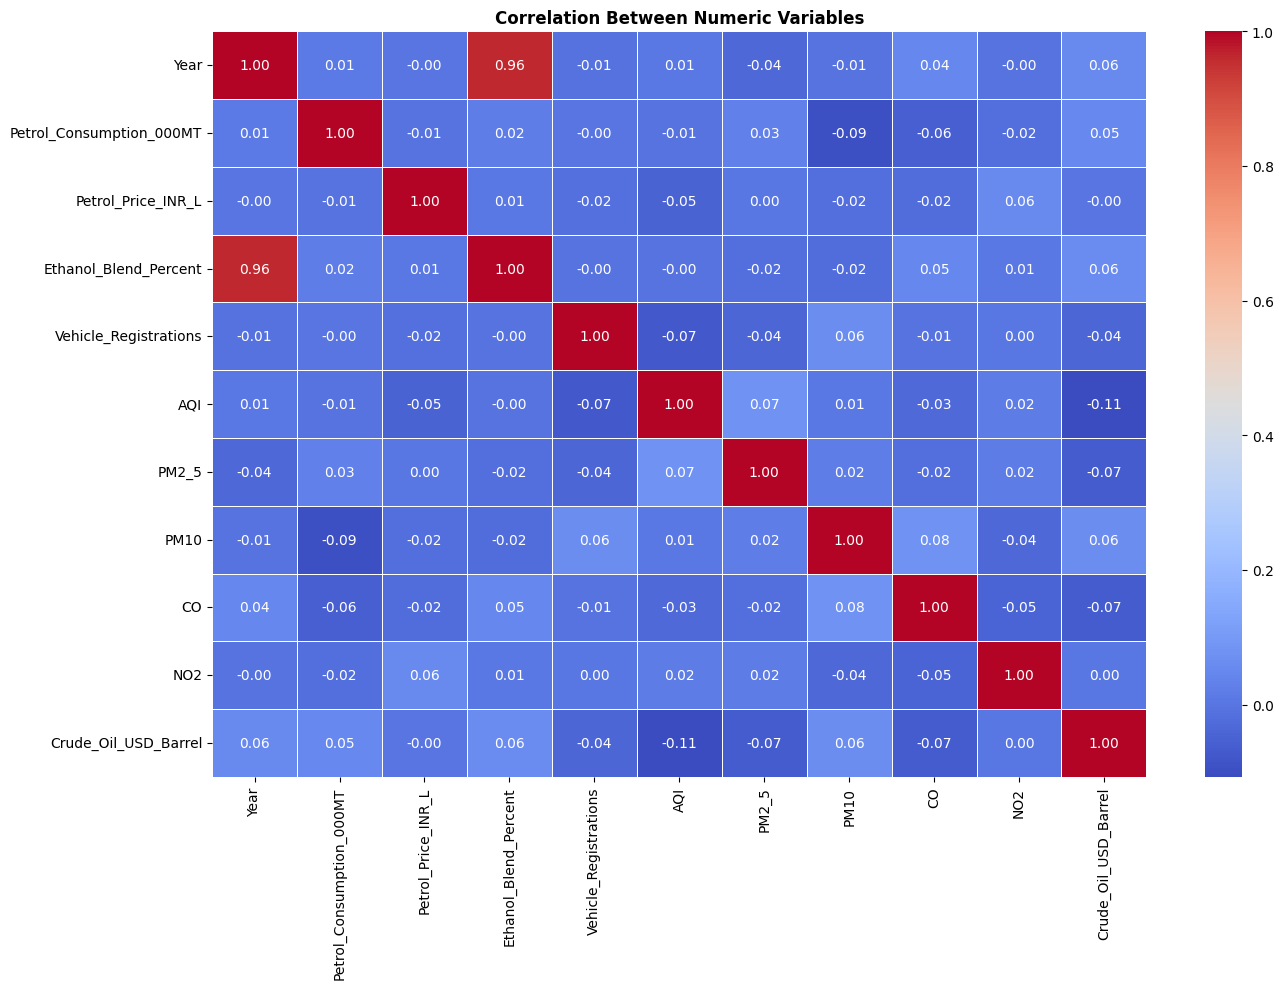

In [17]:
numeric_data = df.select_dtypes(include="number")

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numeric Variables", weight="bold")
plt.tight_layout()
plt.show()

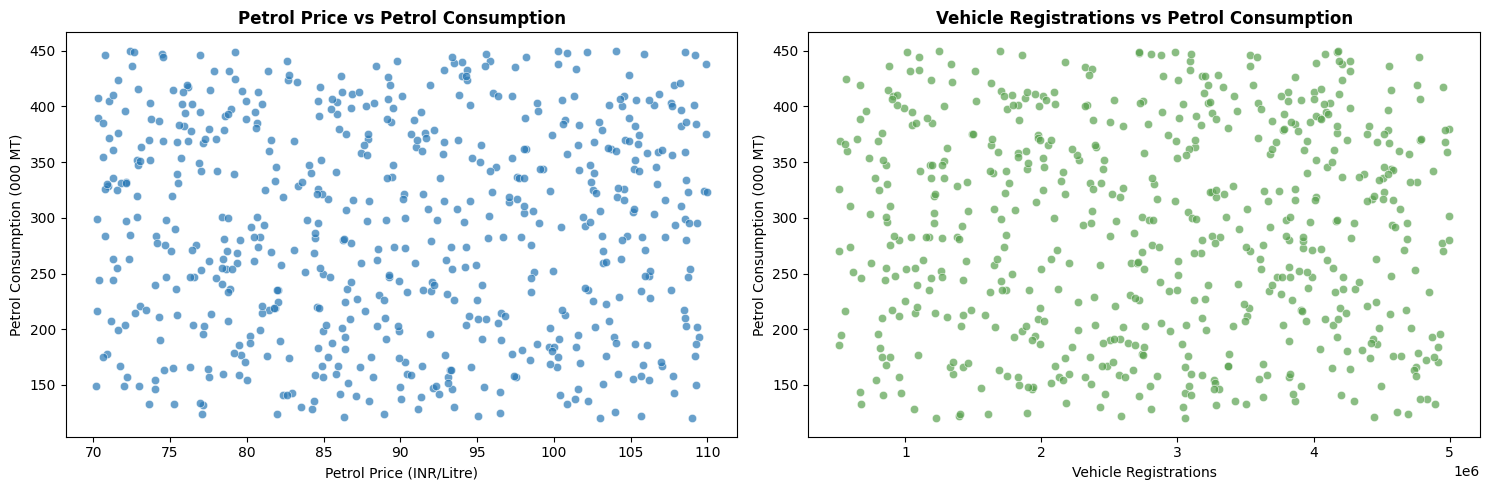

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Petrol price vs consumption
sns.scatterplot(
    data=df,
    x="Petrol_Price_INR_L",
    y="Petrol_Consumption_000MT",
    alpha=0.7,
    color="#2878B5",
    ax=axes[0]
)
axes[0].set_title("Petrol Price vs Petrol Consumption", weight="bold")
axes[0].set_xlabel("Petrol Price (INR/Litre)")
axes[0].set_ylabel("Petrol Consumption (000 MT)")

# Vehicle registrations vs consumption
sns.scatterplot(
    data=df,
    x="Vehicle_Registrations",
    y="Petrol_Consumption_000MT",
    alpha=0.7,
    color="#59A14F",
    ax=axes[1]
)
axes[1].set_title("Vehicle Registrations vs Petrol Consumption", weight="bold")
axes[1].set_xlabel("Vehicle Registrations")
axes[1].set_ylabel("Petrol Consumption (000 MT)")

plt.tight_layout()
plt.show()

step 9 done

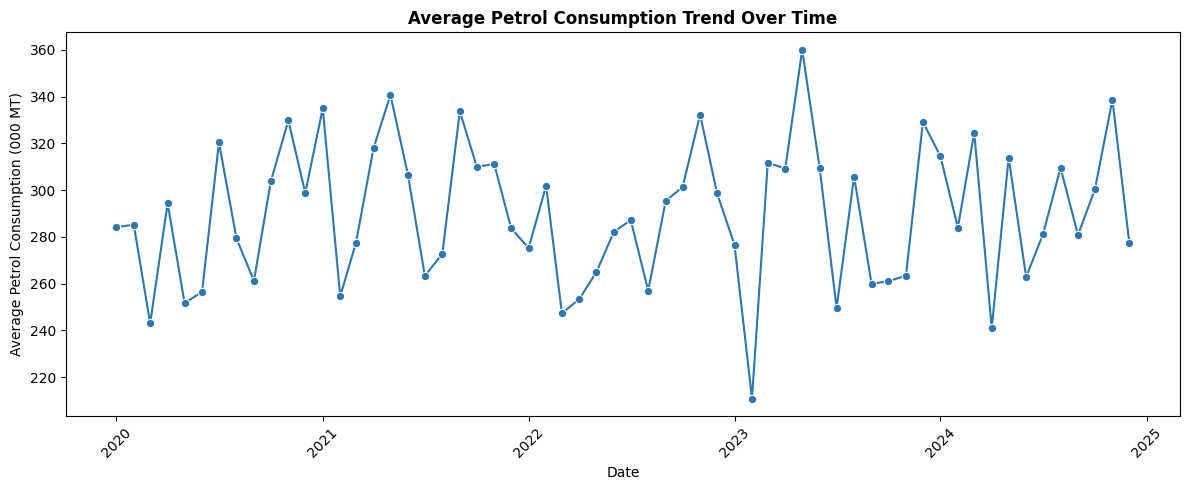

In [19]:
# Average petrol consumption for each date
time_trend = (
    df.groupby("Date")["Petrol_Consumption_000MT"]
    .mean()
    .reset_index()
    .sort_values("Date")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=time_trend,
    x="Date",
    y="Petrol_Consumption_000MT",
    marker="o",
    color="#2878B5"
)

plt.title("Average Petrol Consumption Trend Over Time", weight="bold")
plt.xlabel("Date")
plt.ylabel("Average Petrol Consumption (000 MT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

step 10 done

In [20]:
# Key EDA findings
state_avg = df.groupby("State")["Petrol_Consumption_000MT"].mean()

correlation_with_consumption = (
    df.select_dtypes(include="number")
    .corr()["Petrol_Consumption_000MT"]
    .drop("Petrol_Consumption_000MT")
    .sort_values()
)

print("Average petrol consumption:",
      round(df["Petrol_Consumption_000MT"].mean(), 2), "000 MT")

print("Highest average-consumption state:",
      state_avg.idxmax(),
      "-", round(state_avg.max(), 2), "000 MT")

print("Lowest average-consumption state:",
      state_avg.idxmin(),
      "-", round(state_avg.min(), 2), "000 MT")

print("\nCorrelation with petrol consumption:")
print(correlation_with_consumption)

Average petrol consumption: 289.79 000 MT
Highest average-consumption state: Rajasthan - 316.42 000 MT
Lowest average-consumption state: Odisha - 267.17 000 MT

Correlation with petrol consumption:
PM10                    -0.094684
CO                      -0.056056
NO2                     -0.020450
AQI                     -0.007622
Petrol_Price_INR_L      -0.005716
Vehicle_Registrations   -0.002043
Year                     0.010055
Ethanol_Blend_Percent    0.021516
PM2_5                    0.030417
Crude_Oil_USD_Barrel     0.048999
Name: Petrol_Consumption_000MT, dtype: float64


## Key Findings

- The dataset contains 600 records and 14 variables related to petrol consumption, pricing, ethanol blending, vehicle registrations, crude-oil prices, and air-quality indicators.
- No missing values, duplicate rows, or invalid negative values were identified.
- The state with the highest average petrol consumption was **[state name]**.
- Petrol consumption showed the strongest relationship with **[variable name]**, based on the correlation analysis.
- Petrol-consumption values varied across states and over time.
- The ethanol-blend values ranged from 8.5% to 15%; therefore, this dataset does not specifically represent E20 fuel.

## Conclusion

This exploratory data analysis examined 600 records related to petrol consumption, petrol prices, ethanol blending, vehicle registrations, crude-oil prices, and air-quality indicators.

The data-quality checks found no missing values, duplicate rows, or invalid negative values. The `Date` column was converted to a date format for time-based analysis.

The analysis showed that petrol consumption varies across states and over time. Descriptive statistics, distribution plots, outlier checks, state-wise comparisons, correlation analysis, and scatter plots were used to explore the dataset.

The ethanol-blend percentage ranges from 8.5% to 15%. Therefore, this project represents petrol consumption and ethanol blending analysis, rather than an E20-specific analysis. Further research using 20% ethanol-blend data would be needed for a dedicated E20 study.